<a href="https://colab.research.google.com/github/SrishanthGorla/SERAI/blob/main/Animals_Classifier_EXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Original training images:", x_train.shape)
print("Original testing images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2292s 13us/step
Original training images: (50000, 32, 32, 3)
Original testing images: (10000, 32, 32, 3)


In [ ]:
animal_classes = [2, 3, 4, 5, 6, 7]

class_names = [
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse"
]

# Flatten labels
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# Select animal images
train_mask = np.isin(y_train_flat, animal_classes)
test_mask = np.isin(y_test_flat, animal_classes)

x_train_animals = x_train[train_mask]
y_train_animals = y_train_flat[train_mask]

x_test_animals = x_test[test_mask]
y_test_animals = y_test_flat[test_mask]

print("Animal training images:", x_train_animals.shape)
print("Animal testing images:", x_test_animals.shape)

Animal training images: (30000, 32, 32, 3)
Animal testing images: (6000, 32, 32, 3)


In [ ]:
label_mapping = {
    2: 0,  # Bird
    3: 1,  # Cat
    4: 2,  # Deer
    5: 3,  # Dog
    6: 4,  # Frog
    7: 5   # Horse
}

y_train_animals = np.array([
    label_mapping[label]
    for label in y_train_animals
])

y_test_animals = np.array([
    label_mapping[label]
    for label in y_test_animals
])

print("New training labels:", np.unique(y_train_animals))
print("New testing labels:", np.unique(y_test_animals))

New training labels: [0 1 2 3 4 5]
New testing labels: [0 1 2 3 4 5]


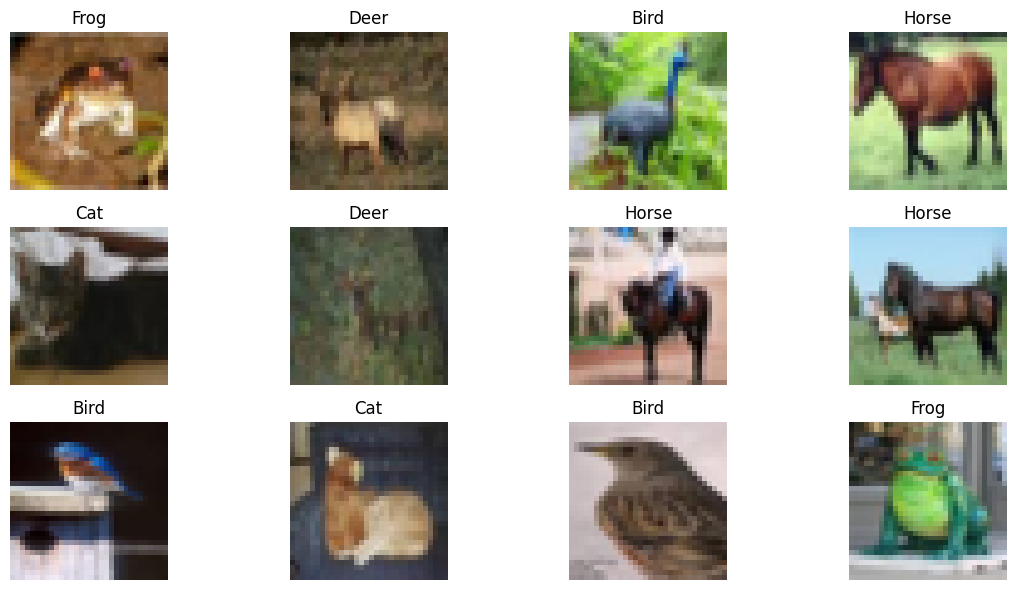

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_train_animals[i])

    plt.title(class_names[y_train_animals[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
x_train_animals = x_train_animals.astype("float32") / 255.0
x_test_animals = x_test_animals.astype("float32") / 255.0

print("Minimum pixel value:", x_train_animals.min())
print("Maximum pixel value:", x_train_animals.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        6,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,294 (1.36 MB)

 Trainable params: 356,294 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    x_train_animals,
    y_train_animals,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 37s 163ms/step - accuracy: 0.3840 - loss: 1.5030 - val_accuracy: 0.4530 - val_loss: 1.3583
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 42s 168ms/step - accuracy: 0.5320 - loss: 1.2140 - val_accuracy: 0.5277 - val_loss: 1.1859
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 45s 185ms/step - accuracy: 0.5923 - loss: 1.0741 - val_accuracy: 0.5910 - val_loss: 1.0477
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 186ms/step - accuracy: 0.6304 - loss: 0.9838 - val_accuracy: 0.6453 - val_loss: 0.9464
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 33s 156ms/step - accuracy: 0.6663 - loss: 0.8950 - val_accuracy: 0.6607 - val_loss: 0.9021
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 155ms/step - accuracy: 0.6955 - loss: 0.8238 - val_accuracy: 0.6920 - val_loss: 0.8596
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 34s 158ms/step - accuracy: 0.7138 - loss: 0.7733 - val_accuracy: 0.6707 - val_loss: 0.8778
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - accuracy: 0.7384 - loss: 0

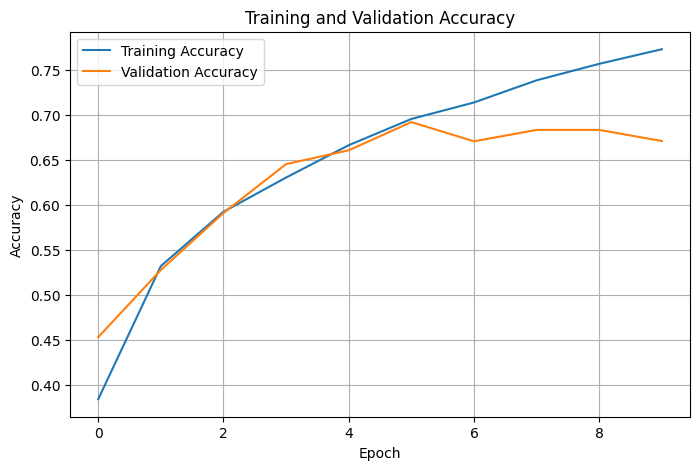

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test_animals,
    y_test_animals,
    verbose=0
)

print("Clean Test Loss:", test_loss)
print("Clean Test Accuracy:", test_accuracy)

Clean Test Loss: 0.9592005014419556
Clean Test Accuracy: 0.6618333458900452


In [ ]:
y_probability = model.predict(
    x_test_animals
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predictions generated successfully.")

188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Predictions generated successfully.


In [ ]:
accuracy = accuracy_score(
    y_test_animals,
    y_pred
)

precision = precision_score(
    y_test_animals,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test_animals,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test_animals,
    y_pred,
    average="weighted"
)

print("\nBASELINE PERFORMANCE")
print("--------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


BASELINE PERFORMANCE
--------------------
Accuracy  : 0.6618
Precision : 0.6730
Recall    : 0.6618
F1-Score  : 0.6523


In [ ]:
print(
    classification_report(
        y_test_animals,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        Bird       0.62      0.71      0.66      1000
         Cat       0.58      0.47      0.52      1000
        Deer       0.72      0.60      0.65      1000
         Dog       0.77      0.45      0.57      1000
        Frog       0.61      0.93      0.74      1000
       Horse       0.74      0.80      0.77      1000

    accuracy                           0.66      6000
   macro avg       0.67      0.66      0.65      6000
weighted avg       0.67      0.66      0.65      6000



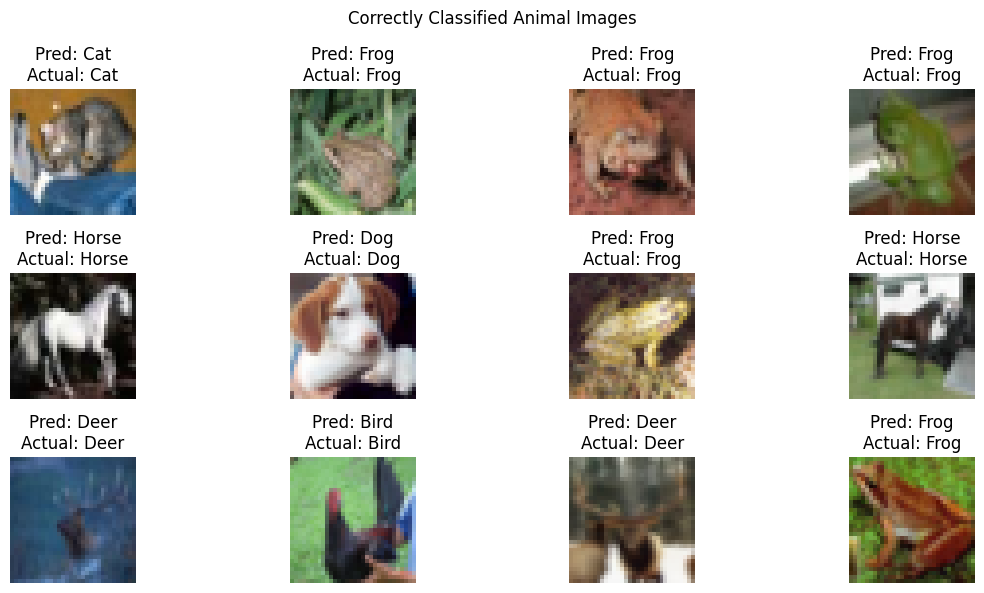

In [ ]:
correct_indices = np.where(
    y_pred == y_test_animals
)[0]

plt.figure(figsize=(12, 6))

for i, idx in enumerate(correct_indices[:12]):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        x_test_animals[idx]
    )

    plt.title(
        f"Pred: {class_names[y_pred[idx]]}\n"
        f"Actual: {class_names[y_test_animals[idx]]}"
    )

    plt.axis("off")

plt.suptitle("Correctly Classified Animal Images")

plt.tight_layout()
plt.show()

In [ ]:
incorrect_indices = np.where(
    y_pred != y_test_animals
)[0]

print(
    "Number of incorrect predictions:",
    len(incorrect_indices)
)

Number of incorrect predictions: 2029


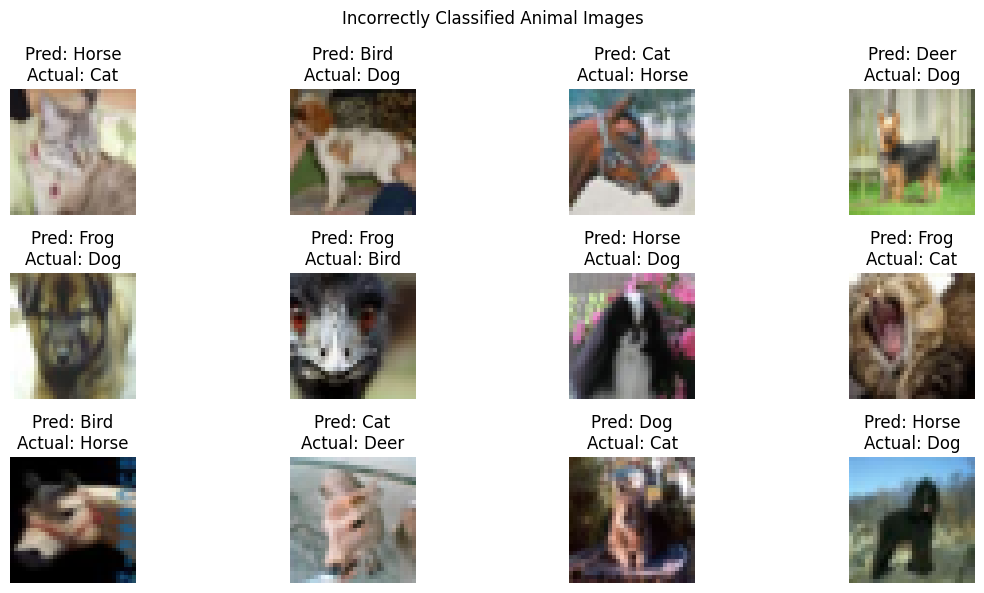

In [ ]:
plt.figure(figsize=(12, 6))

for i, idx in enumerate(incorrect_indices[:12]):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        x_test_animals[idx]
    )

    plt.title(
        f"Pred: {class_names[y_pred[idx]]}\n"
        f"Actual: {class_names[y_test_animals[idx]]}"
    )

    plt.axis("off")

plt.suptitle("Incorrectly Classified Animal Images")

plt.tight_layout()
plt.show()

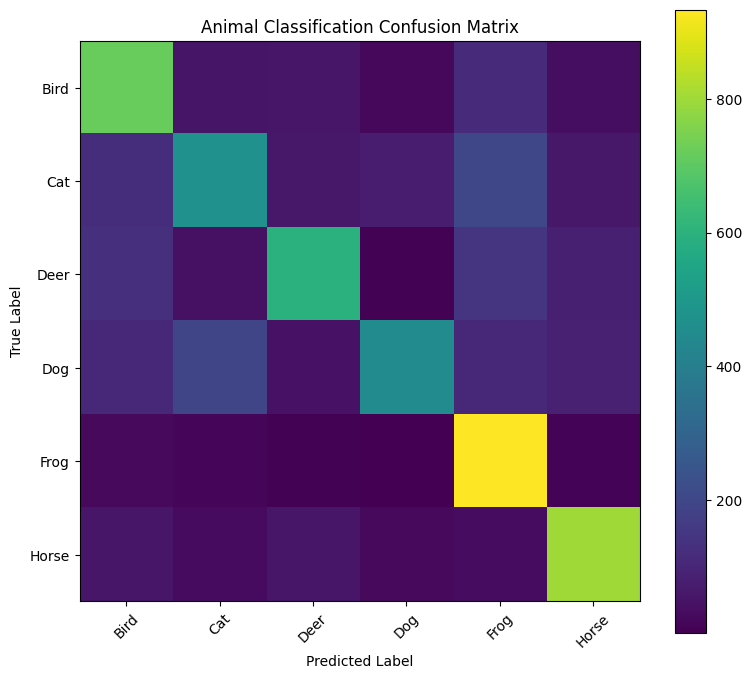

In [ ]:
cm = confusion_matrix(
    y_test_animals,
    y_pred
)

plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.title("Animal Classification Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(
    range(6),
    class_names,
    rotation=45
)

plt.yticks(
    range(6),
    class_names
)

plt.tight_layout()

plt.show()